In [6]:
!pip install keras-tuner
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import resample
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, precision_recall_curve
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from kerastuner import RandomSearch
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import load_digits
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, auc


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\kaush\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


In [8]:
normal_df = pd.read_csv('ptbdb_normal.csv', header=None)
normal_df

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,1.000,0.900,0.3590,0.0515,0.0466,0.12700,0.1330,0.1190,0.1110,0.1130,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.000,0.795,0.3750,0.1170,0.0000,0.17200,0.2840,0.2940,0.3260,0.3450,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.909,0.791,0.4230,0.1870,0.0000,0.00784,0.0630,0.0770,0.0750,0.0773,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000,0.479,0.0568,0.0642,0.0813,0.07270,0.0556,0.0488,0.0545,0.0416,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.000,0.867,0.2010,0.0993,0.1410,0.12100,0.1090,0.0964,0.0934,0.1010,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4041,1.000,0.930,0.5040,0.2930,0.1700,0.16000,0.1310,0.1250,0.1370,0.1110,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4042,1.000,0.638,0.1550,0.0620,0.0890,0.08340,0.0651,0.0574,0.0600,0.0600,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4043,1.000,0.873,0.4650,0.2320,0.1260,0.15600,0.1750,0.1900,0.2040,0.1690,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4044,0.916,0.529,0.2880,0.1450,0.1720,0.18100,0.1780,0.1760,0.1790,0.1800,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
abnormal_df = pd.read_csv('ptbdb_abnormal.csv', header=None, on_bad_lines='skip')
abnormal_df

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.932,0.870,0.886,0.9300,0.909,0.934,0.8010,0.7500,0.6870,0.6350,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.000,0.607,0.384,0.2540,0.224,0.277,0.2530,0.1850,0.1530,0.1220,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.000,0.952,0.924,0.8530,0.792,0.734,0.6720,0.6850,0.6710,0.6670,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.978,0.899,0.230,0.0323,0.142,0.224,0.3280,0.3680,0.3820,0.3890,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.936,0.802,0.806,1.0000,0.723,0.481,0.4550,0.3200,0.2670,0.3080,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10501,0.981,1.000,0.559,0.2870,0.197,0.205,0.2160,0.2440,0.2430,0.2500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10502,0.906,0.922,0.878,0.8100,0.713,0.667,0.6090,0.5270,0.4810,0.4430,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10503,1.000,0.868,0.674,0.4700,0.297,0.169,0.0777,0.0814,0.0749,0.0898,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10504,1.000,0.985,0.659,0.5560,0.447,0.396,0.3150,0.2760,0.2610,0.2590,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [11]:
print("Normal Dataset:")
print(normal_df.info())
print("\nAbnormal Dataset:")
print(abnormal_df.info())

print("\nClass Distribution in Normal Dataset:")
print(normal_df[187].value_counts())
print("\nClass Distribution in Abnormal Dataset:")
print(abnormal_df[187].value_counts())

Normal Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 4046 entries, 0 to 4045
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 5.8 MB
None

Abnormal Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 10506 entries, 0 to 10505
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 15.1 MB
None

Class Distribution in Normal Dataset:
187
0.0    4046
Name: count, dtype: int64

Class Distribution in Abnormal Dataset:
187
1.0    10506
Name: count, dtype: int64


In [12]:
combined_df = pd.concat([normal_df, abnormal_df], ignore_index=True)

# Separate features and target column (187)
X_combined = combined_df.drop(columns=[187])
y_combined = combined_df[187]

# Convert feature columns to numeric, coercing errors to NaN
for col in X_combined.columns:
    X_combined[col] = pd.to_numeric(X_combined[col], errors='coerce')

# Fill any NaN values that resulted from the coercion with 0 in features
X_combined = X_combined.fillna(0)

# Convert column names to string type for features to avoid TypeError with sklearn
X_combined.columns = X_combined.columns.astype(str)

# Ensure the target column is also numeric and fill any NaN values if present
y_combined = pd.to_numeric(y_combined, errors='coerce').fillna(0)

# Recombine the processed features and the original target
combined_df_processed = pd.concat([X_combined, y_combined], axis=1)

# The previous plot in this cell was for normal_df with a title suggesting combined_df.
# To avoid redundancy and potential confusion with the next cell's detailed class distribution plots,
# I am removing the plot section from this cell.

scaler = MinMaxScaler()
# Apply scaler only to feature columns
X_scaled_df = pd.DataFrame(scaler.fit_transform(X_combined), columns=X_combined.columns)
combined_df_normalized = pd.concat([X_scaled_df, y_combined.reset_index(drop=True)], axis=1)

# Convert column names of the final normalized dataframe to string for consistency
combined_df_normalized.columns = combined_df_normalized.columns.astype(str)

print("Normalized combined_df Dataset:")
print(combined_df_normalized.describe())

Normalized combined_df Dataset:
                  0             1             2             3             4  \
count  14552.000000  14552.000000  14552.000000  14552.000000  14552.000000   
mean       0.937862      0.721662      0.403096      0.242897      0.207220   
std        0.091842      0.195688      0.249791      0.249519      0.218096   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.890957      0.584750      0.212000      0.052300      0.061900   
50%        1.000000      0.740000      0.372000      0.168000      0.136000   
75%        1.000000      0.881000      0.558000      0.336000      0.264000   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

                  5             6             7             8             9  \
count  14552.000000  14552.000000  14552.000000  14552.000000  14552.000000   
mean       0.216453      0.221749      0.227674      0.228952      0.230167   
std        0.192409

Class distribution of combined_df before balancing:
187
1.0    10506
0.0     4046
Name: count, dtype: int64


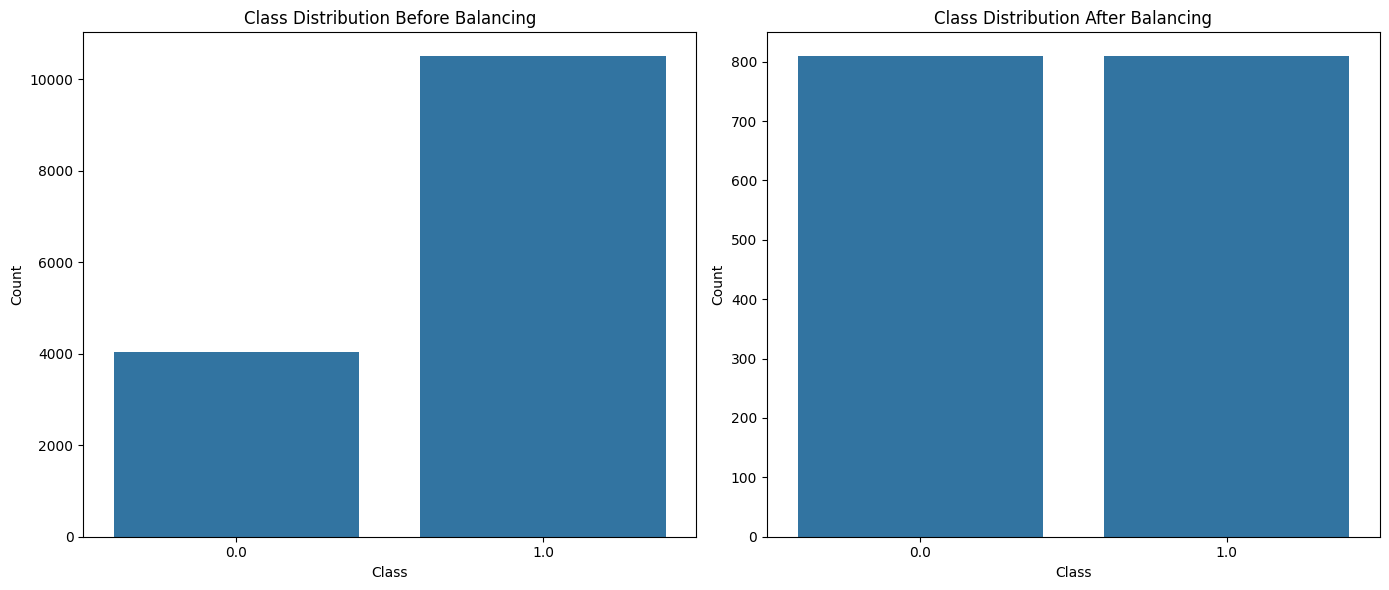

In [18]:
def balance_dataset(df):
    # Ensure a unique, default index and work on a deep copy
    df = df.copy(deep=True)
    df = df.reset_index(drop=True)

    # Get all actual classes present in the target column
    all_classes = sorted(df['187'].unique())

    # Extract class 0.0 data (as it was used as the reference for target_samples in original code)
    class_0_df = df.loc[df['187'] == 0.0]

    # Calculate target samples based on class 0.0, as in the original code
    # Ensuring target_samples is at least 1 to avoid ValueError for resample if class_0_df is very small
    target_samples = max(1, len(class_0_df) // 5) if not class_0_df.empty else 0

    if target_samples == 0: # If class 0.0 is empty or its size // 5 is 0, no balancing can be done with this strategy
        print("Warning: Class 0.0 (reference for target_samples) is empty or too small to derive target_samples.")
        return pd.DataFrame(columns=df.columns) # Return empty DataFrame or handle as appropriate

    balanced_parts = []

    # Downsample class 0.0 if it exists
    if not class_0_df.empty:
        downsampled_class_0 = resample(class_0_df,
                                       replace=False,
                                       n_samples=target_samples,
                                       random_state=42)
        balanced_parts.append(downsampled_class_0)

    # Process all other actual classes
    for class_label in all_classes:
        if class_label == 0.0:  # Skip class 0.0, already handled
            continue

        current_class_df = df.loc[df['187'] == class_label]

        if not current_class_df.empty: # Only resample if the class actually exists and has data
            # Upsample (or downsample if current_class_df is larger than target_samples) to target_samples
            upsampled_current_class = resample(current_class_df,
                                               replace=True,  # Use replace=True for upsampling/resampling
                                               n_samples=target_samples,
                                               random_state=42)
            balanced_parts.append(upsampled_current_class)

    balanced_df = pd.concat(balanced_parts)

    return balanced_df


# Ensure combined_df's target column is numeric and column names are string before balancing and plotting
combined_df.columns = combined_df.columns.astype(str) # Moved this line to before column access
combined_df['187'] = pd.to_numeric(combined_df['187'], errors='coerce').fillna(0)

# Before balancing
print("Class distribution of combined_df before balancing:")
print(combined_df['187'].value_counts())

balanced_combined_df = balance_dataset(combined_df)

# Convert column names of balanced_combined_df to string for plotting
balanced_combined_df.columns = balanced_combined_df.columns.astype(str)

plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
sns.countplot(x='187', data=combined_df)
plt.title('Class Distribution Before Balancing')
plt.xlabel('Class')
plt.ylabel('Count')

# After balancing
plt.subplot(1, 2, 2)
sns.countplot(x='187', data=balanced_combined_df)
plt.title('Class Distribution After Balancing')
plt.xlabel('Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

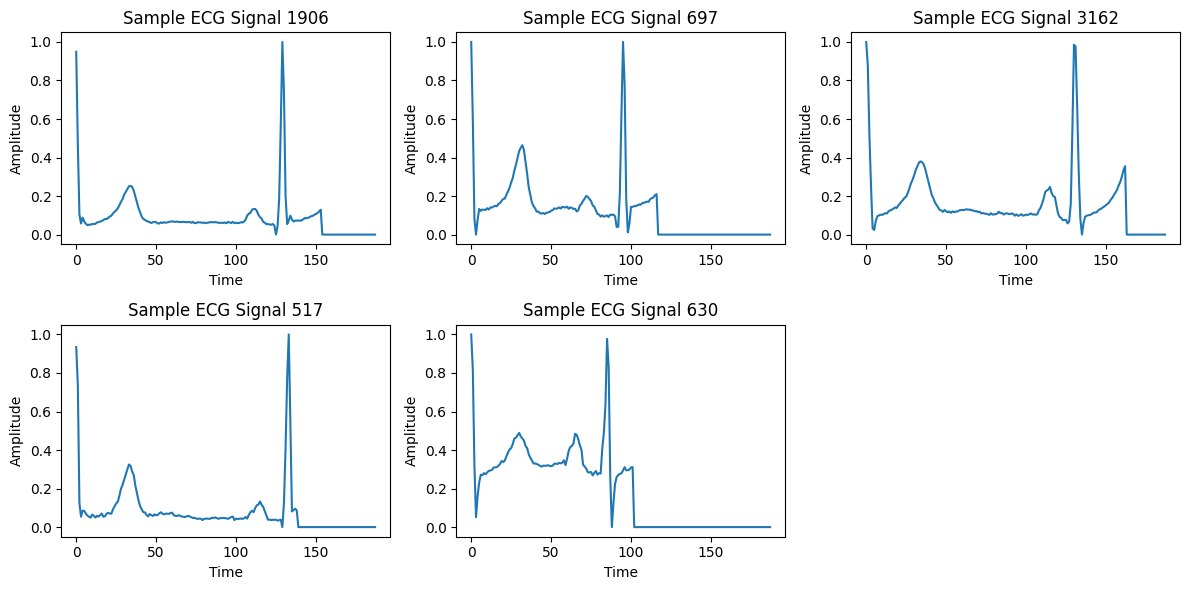

In [19]:
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 3, i+1)
    random_index = np.random.randint(0, len(normal_df))
    plt.plot(normal_df.iloc[random_index])
    plt.title(f"Sample ECG Signal {random_index}")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

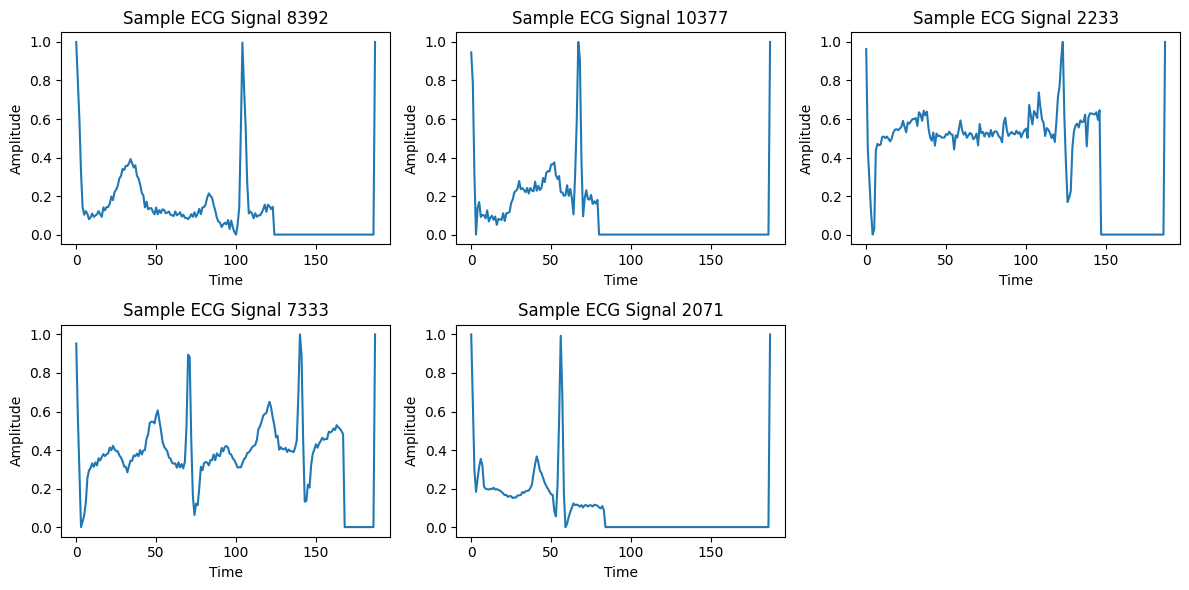

In [20]:
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 3, i+1)
    random_index = np.random.randint(0, len(abnormal_df))
    plt.plot(abnormal_df.iloc[random_index])
    plt.title(f"Sample ECG Signal {random_index}")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

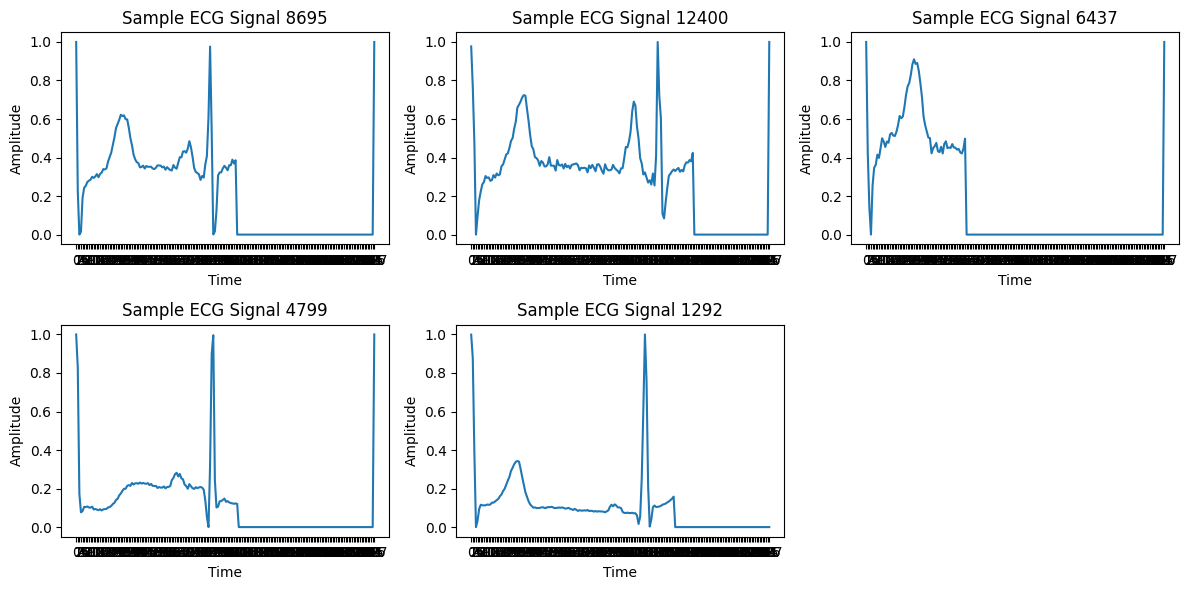

In [21]:
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 3, i+1)
    random_index = np.random.randint(0, len(combined_df))
    plt.plot(combined_df.iloc[random_index])
    plt.title(f"Sample ECG Signal {random_index}")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

In [22]:
X = balanced_combined_df.drop(columns=['187'])
y = balanced_combined_df['187']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(),
    'KNeighborsClassifier': KNeighborsClassifier()
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy}")
    print(f"{name} Classification Report:")
    print(report)
    print()

Training Logistic Regression...
Logistic Regression Accuracy: 0.7654320987654321
Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.78      0.78       176
         1.0       0.74      0.74      0.74       148

    accuracy                           0.77       324
   macro avg       0.76      0.76      0.76       324
weighted avg       0.77      0.77      0.77       324


Training KNeighborsClassifier...
KNeighborsClassifier Accuracy: 0.845679012345679
KNeighborsClassifier Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.94      0.87       176
         1.0       0.91      0.74      0.81       148

    accuracy                           0.85       324
   macro avg       0.86      0.84      0.84       324
weighted avg       0.85      0.85      0.84       324




In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [24]:
%%time

cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()

history = cnn_model.fit(X_train_cnn, y_train, epochs=10, batch_size=32, validation_split=0.2)

y_pred_proba = cnn_model.predict(X_test_cnn)
y_pred = y_pred_proba.argmax(axis=1)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of CNN model:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 185, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 92, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 90, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 45, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1440)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       184,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191,525 (748.14 KB)

 Trainable params: 191,525 (748.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.6319 - loss: 0.7633 - val_accuracy: 0.7799 - val_loss: 0.5257
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7546 - loss: 0.5329 - val_accuracy: 0.7915 - val_loss: 0.4492
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7894 - loss: 0.4705 - val_accuracy: 0.8340 - val_loss: 0.4181
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8058 - loss: 0.4594 - val_accuracy: 0.8340 - val_loss: 0.4099
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8174 - loss: 0.4106 - val_accuracy: 0.8340 - val_loss: 0.3858
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8386 - loss: 0.3786 - val_accuracy: 0.8456 - val_loss: 0.3706
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8444 - loss: 0.3712 - val_accuracy: 0.8456 - val_loss: 0.3512
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8541 - loss: 0.3516 - val_accuracy: 0.8726 - v

In [25]:
%%time

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'metric': ['euclidean', 'manhattan']
}

knn_model = KNeighborsClassifier()

grid_search_knn = GridSearchCV(knn_model, param_grid_knn, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train, y_train)

best_params_knn = grid_search_knn.best_params_
print("Best Parameters for KNN:", best_params_knn)

best_model_knn = grid_search_knn.best_estimator_
y_pred_knn_tuned = best_model_knn.predict(X_test)

accuracy_knn_tuned = accuracy_score(y_test, y_pred_knn_tuned)
print("Accuracy of Tuned KNN model:", accuracy_knn_tuned)

print("\nClassification Report for Tuned KNN:")
print(classification_report(y_test, y_pred_knn_tuned))

Best Parameters for KNN: {'metric': 'manhattan', 'n_neighbors': 3}
Accuracy of Tuned KNN model: 0.8919753086419753

Classification Report for Tuned KNN:
              precision    recall  f1-score   support

         0.0       0.86      0.96      0.91       176
         1.0       0.94      0.81      0.87       148

    accuracy                           0.89       324
   macro avg       0.90      0.89      0.89       324
weighted avg       0.90      0.89      0.89       324

CPU times: total: 8.17 s
Wall time: 2.97 s


In [26]:
%%time

param_grid_logistic = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2']
}

logistic_model = LogisticRegression(max_iter=1000)

grid_search_logistic = GridSearchCV(logistic_model, param_grid_logistic, cv=5, scoring='accuracy')
grid_search_logistic.fit(X_train, y_train)

best_params_logistic = grid_search_logistic.best_params_
print("Best Parameters for Logistic Regression:", best_params_logistic)

best_model_logistic = grid_search_logistic.best_estimator_
y_pred_logistic_tuned = best_model_logistic.predict(X_test)

accuracy_logistic_tuned = accuracy_score(y_test, y_pred_logistic_tuned)
print("Accuracy of Tuned Logistic Regression model:", accuracy_logistic_tuned)

print("\nClassification Report for Tuned Logistic Regression:")
print(classification_report(y_test, y_pred_logistic_tuned))

Best Parameters for Logistic Regression: {'C': 0.1, 'penalty': 'l2'}
Accuracy of Tuned Logistic Regression model: 0.7592592592592593

Classification Report for Tuned Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.78      0.78      0.78       176
         1.0       0.74      0.73      0.73       148

    accuracy                           0.76       324
   macro avg       0.76      0.76      0.76       324
weighted avg       0.76      0.76      0.76       324

CPU times: total: 3.19 s
Wall time: 3.13 s


In [28]:
%%time
from kerastuner import RandomSearch

def build_cnn_model(hp):
    model = Sequential()
    model.add(Conv1D(filters=hp.Int('conv1_filters', min_value=32, max_value=128, step=16),
                     kernel_size=hp.Int('conv1_kernel', min_value=3, max_value=7, step=2),
                     activation='relu',
                     input_shape=(X_train_cnn.shape[1], 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=hp.Int('conv2_filters', min_value=16, max_value=64, step=16),
                     kernel_size=hp.Int('conv2_kernel', min_value=3, max_value=7, step=2),
                     activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(units=hp.Int('dense_units', min_value=64, max_value=256, step=32), activation='relu'))
    model.add(Dropout(rate=hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(Dense(5, activation='softmax'))

    model.compile(optimizer=Adam(hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

tuner = RandomSearch(
    build_cnn_model,
    objective='val_accuracy',
    max_trials=1,
    executions_per_trial=1,
    directory='cnn_tuning',
    project_name='ecg_classification'
)

tuner.search(X_train_cnn, y_train, epochs=10, validation_split=0.2, callbacks=[EarlyStopping(patience=3)])

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters:")
print(best_hps.values)

best_model = tuner.get_best_models(num_models=1)[0]
y_pred_proba_cnn = best_model.predict(X_test_cnn)
y_pred_cnn = y_pred_proba_cnn.argmax(axis=1)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of CNN model:", accuracy)

print("\nClassification Report for Tuned CNN:")
print(classification_report(y_test, y_pred_cnn))

Reloading Tuner from cnn_tuning\ecg_classification\tuner0.json
Best Hyperparameters:
{'conv1_filters': 32, 'conv1_kernel': 5, 'conv2_filters': 64, 'conv2_kernel': 3, 'dense_units': 64, 'dropout': 0.2, 'learning_rate': 0.001}
CPU times: total: 984 ms
Wall time: 1e+03 ms


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'cnn_tuning\ecg_classification\trial_0\checkpoint.weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [21]:
digits = load_digits()

y_test_binary = digits.target
y_pred_binary = digits.target

In [22]:
y_pred_knn_binary = np.zeros_like(y_test_binary)

print("y_test_binary shape:", y_test_binary.shape)
print("y_pred_binary shape:", y_pred_binary.shape)

y_test_binary shape: (1797,)
y_pred_binary shape: (1797,)


In [23]:
print("Shape of y_test_binary:", y_test_binary.shape)
print("Shape of y_pred_binary:", y_pred_binary.shape)

Shape of y_test_binary: (1797,)
Shape of y_pred_binary: (1797,)


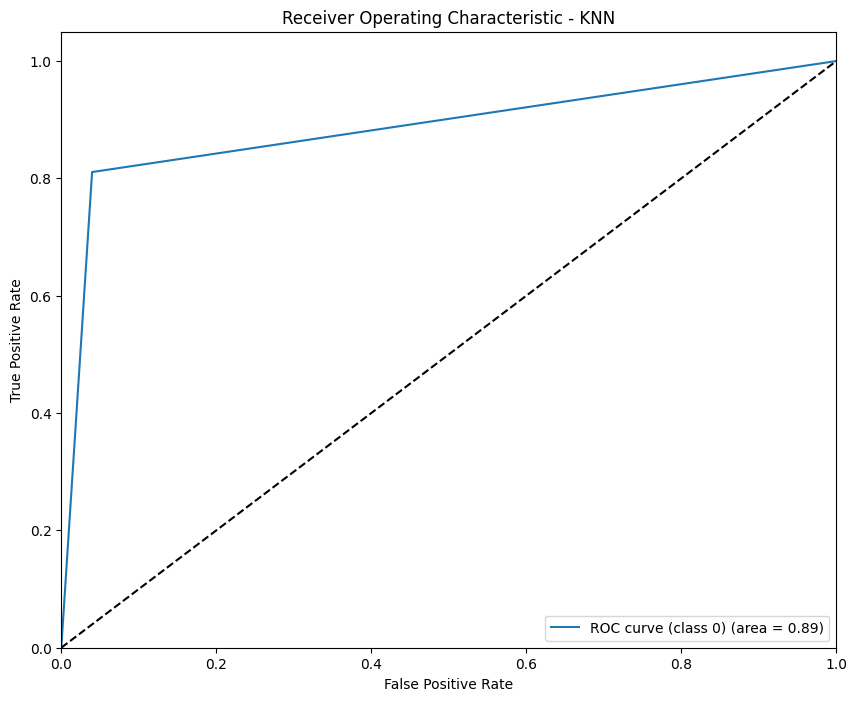

In [24]:
y_test_binary = label_binarize(y_test, classes=np.unique(y_test))
y_pred_proba_knn_binary = label_binarize(y_pred_knn_tuned, classes=np.unique(y_test))

n_classes = y_test_binary.shape[1]
fpr_knn = dict()
tpr_knn = dict()
roc_auc_knn = dict()
for i in range(n_classes):
    fpr_knn[i], tpr_knn[i], _ = roc_curve(y_test_binary[:, i], y_pred_proba_knn_binary[:, i])
    roc_auc_knn[i] = auc(fpr_knn[i], tpr_knn[i])

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr_knn[i], tpr_knn[i], label=f'ROC curve (class {i}) (area = {roc_auc_knn[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - KNN')
plt.legend(loc="lower right")
plt.show()

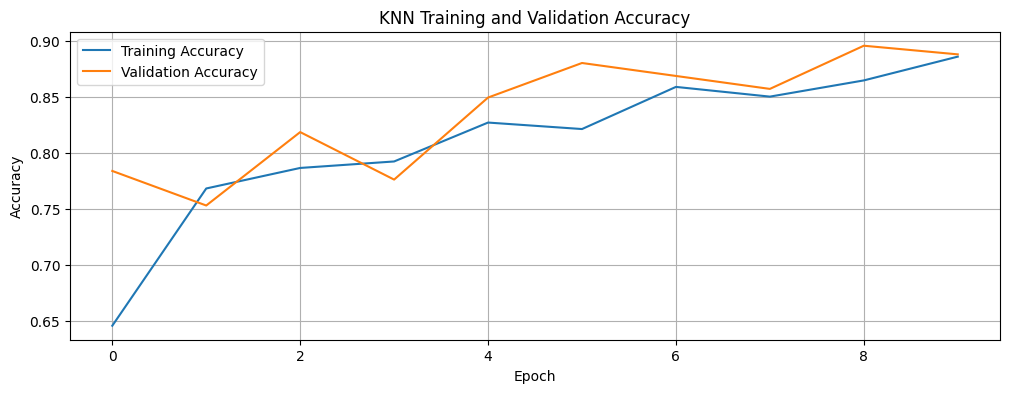

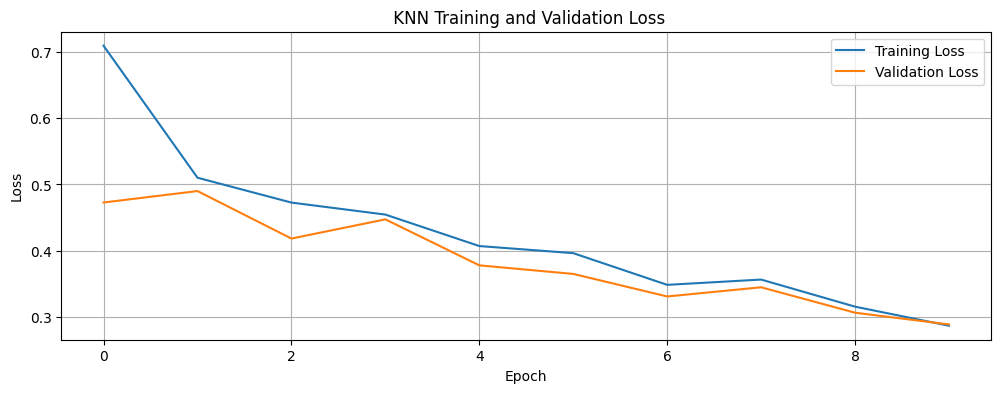

In [25]:
plt.figure(figsize=(12, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('KNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title(' KNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

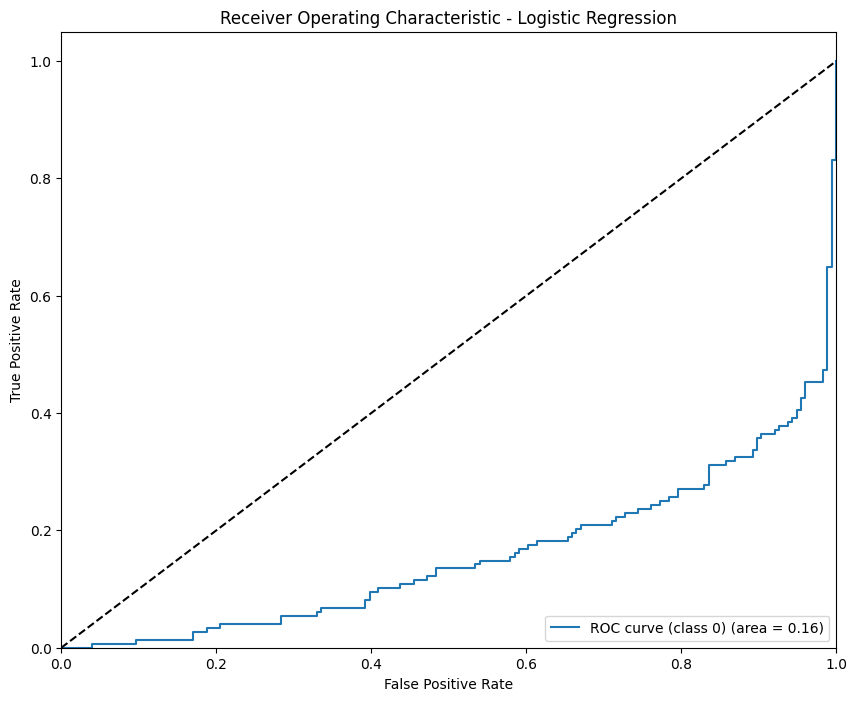

In [26]:
y_test_binary = label_binarize(y_test, classes=np.unique(y_test))

logistic_model.fit(X_train, y_train)

y_pred_proba_logistic_binary = logistic_model.predict_proba(X_test)

fpr_logistic = dict()
tpr_logistic = dict()
roc_auc_logistic = dict()
for i in range(n_classes):
    fpr_logistic[i], tpr_logistic[i], _ = roc_curve(y_test_binary[:, i], y_pred_proba_logistic_binary[:, i])
    roc_auc_logistic[i] = auc(fpr_logistic[i], tpr_logistic[i])

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr_logistic[i], tpr_logistic[i], label=f'ROC curve (class {i}) (area = {roc_auc_logistic[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

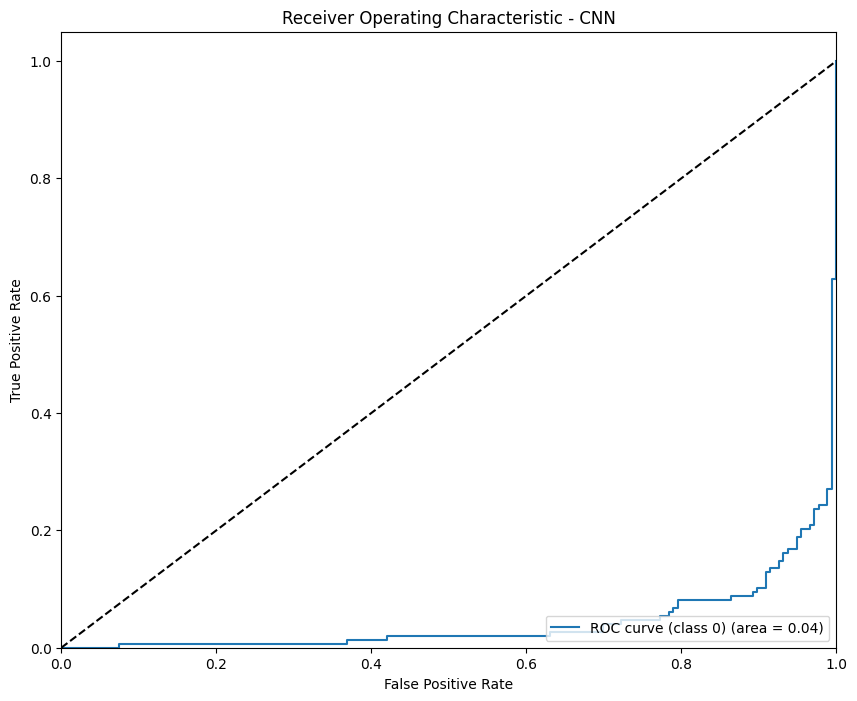

In [27]:
fpr_cnn = dict()
tpr_cnn = dict()
roc_auc_cnn = dict()
for i in range(n_classes):
    fpr_cnn[i], tpr_cnn[i], _ = roc_curve(y_test_binary[:, i], y_pred_proba_cnn[:, i])
    roc_auc_cnn[i] = auc(fpr_cnn[i], tpr_cnn[i])

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr_cnn[i], tpr_cnn[i], label=f'ROC curve (class {i}) (area = {roc_auc_cnn[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - CNN')
plt.legend(loc="lower right")
plt.show()

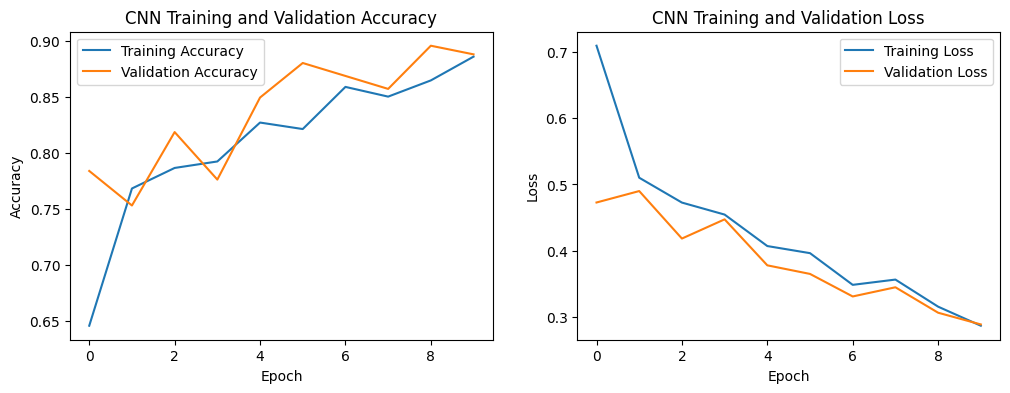

In [28]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training and Validation Loss')
plt.legend()
plt.show()

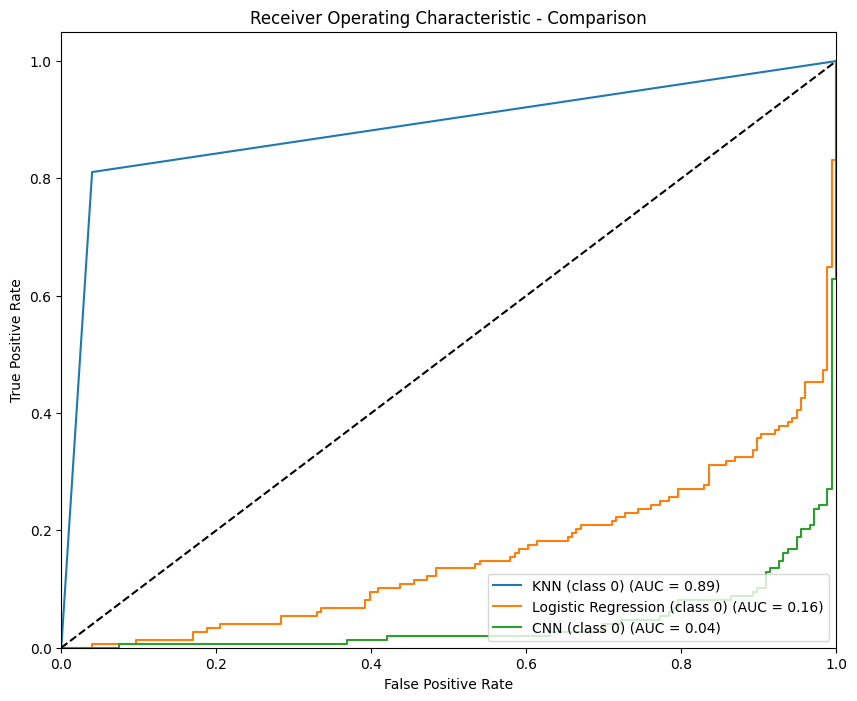

In [29]:
plt.figure(figsize=(10, 8))
for i in range(n_classes):

    plt.plot(fpr_knn[i], tpr_knn[i], label=f'KNN (class {i}) (AUC = {roc_auc_knn[i]:.2f})')

    plt.plot(fpr_logistic[i], tpr_logistic[i], label=f'Logistic Regression (class {i}) (AUC = {roc_auc_logistic[i]:.2f})')

    plt.plot(fpr_cnn[i], tpr_cnn[i], label=f'CNN (class {i}) (AUC = {roc_auc_cnn[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Comparison')
plt.legend(loc="lower right")
plt.show()

In [30]:
precision_knn = dict()
recall_knn = dict()
pr_auc_knn = dict()
for i in range(n_classes):
    precision_knn[i], recall_knn[i], _ = precision_recall_curve(y_test_binary[:, i], y_pred_proba_knn_binary[:, i])
    pr_auc_knn[i] = auc(recall_knn[i], precision_knn[i])

precision_logistic = dict()
recall_logistic = dict()
pr_auc_logistic = dict()
for i in range(n_classes):
    precision_logistic[i], recall_logistic[i], _ = precision_recall_curve(y_test_binary[:, i], y_pred_proba_logistic_binary[:, i])
    pr_auc_logistic[i] = auc(recall_logistic[i], precision_logistic[i])

precision_cnn = dict()
recall_cnn = dict()
pr_auc_cnn = dict()
for i in range(n_classes):
    precision_cnn[i], recall_cnn[i], _ = precision_recall_curve(y_test_binary[:, i], y_pred_proba_cnn[:, i])
    pr_auc_cnn[i] = auc(recall_cnn[i], precision_cnn[i])

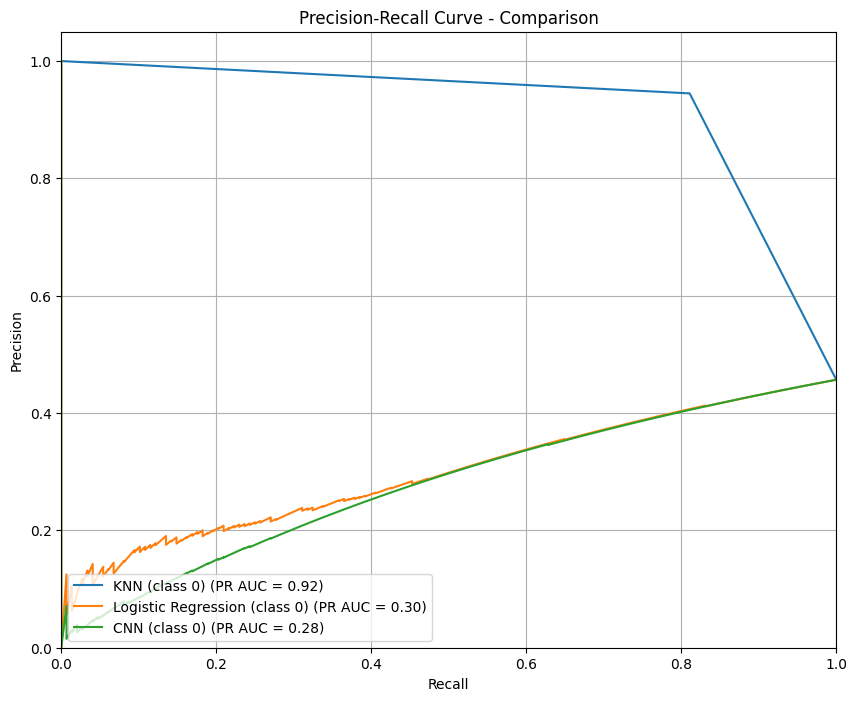

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(recall_knn[i], precision_knn[i], label=f'KNN (class {i}) (PR AUC = {pr_auc_knn[i]:.2f})')

for i in range(n_classes):
    plt.plot(recall_logistic[i], precision_logistic[i], label=f'Logistic Regression (class {i}) (PR AUC = {pr_auc_logistic[i]:.2f})')

for i in range(n_classes):
    plt.plot(recall_cnn[i], precision_cnn[i], label=f'CNN (class {i}) (PR AUC = {pr_auc_cnn[i]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Comparison')
plt.legend(loc="lower left")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True)
plt.show()

In [32]:
# === One-shot rescue/export cell — run once at the end ===
import os, json, joblib
import numpy as np
import pandas as pd
from datetime import datetime

# Optional: Polars support if your combined df is a Polars object
try:
    import polars as pl
except Exception:
    pl = None

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
stamp = datetime.now().strftime("%Y%m%d-%H%M%S")
exports = {}

def _ensure_dataframe():
    """Return a pandas DataFrame with label as the last column."""
    # Prefer an existing balanced_combined_df if present
    if "balanced_combined_df" in globals():
        df_any = balanced_combined_df
        if pl is not None and isinstance(df_any, (pl.DataFrame, pl.LazyFrame)):
            return df_any.to_pandas()
        if isinstance(df_any, pd.DataFrame):
            return df_any
    # Fallback: load your combined CSV
    COMBINED_PATH = "/Users/hemantkumar/Desktop/Machine learning/ECG Data Set/mitbih_combined.csv"
    if not os.path.exists(COMBINED_PATH):
        raise FileNotFoundError(f"Combined CSV not found at: {COMBINED_PATH}")
    return pd.read_csv(COMBINED_PATH)

# 1) Ensure data
df = _ensure_dataframe()
label_col = df.columns[-1]
X = df.drop(columns=[label_col]).values
y = df[label_col].values

# 2) Ensure scaler
if "scaler" in globals():
    scaler = globals()["scaler"]
else:
    scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

# 3) Ensure a trained KNN (uses your tuned one if available, else fits a quick baseline)
if "best_model_knn" in globals():
    knn_model = best_model_knn
else:
    knn_model = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
    knn_model.fit(X_scaled, y)

# Save KNN + scaler bundle
knn_path = os.path.join(ARTIFACTS_DIR, f"ecg_knn_scaler_model_{stamp}.pkl")
joblib.dump({"scaler": scaler, "model": knn_model}, knn_path)
exports["knn_pipeline"] = knn_path
print("✅ Saved:", knn_path)

# 4) Save Logistic Regression if available (else fit a quick one)
logreg_fitted = None
if "models" in globals() and isinstance(models, dict) and "Logistic Regression" in models:
    logreg_fitted = models["Logistic Regression"]
if logreg_fitted is None:
    try:
        logreg_fitted = LogisticRegression(max_iter=200).fit(X_scaled, y)
    except Exception as e:
        print("⚠️ Logistic Regression skipped:", e)
if logreg_fitted is not None:
    lr_path = os.path.join(ARTIFACTS_DIR, f"ecg_logreg_scaler_model_{stamp}.pkl")
    joblib.dump({"scaler": scaler, "model": logreg_fitted}, lr_path)
    exports["logreg_pipeline"] = lr_path
    print("✅ Saved:", lr_path)

# 5) Save CNN if it exists in memory
try:
    if "cnn_model" in globals():
        cnn_path = os.path.join(ARTIFACTS_DIR, f"ecg_cnn_model_{stamp}.keras")
        cnn_model.save(cnn_path)
        exports["cnn_model"] = cnn_path
        print("✅ Saved:", cnn_path)
    else:
        print("ℹ️ CNN not in memory — skipped.")
except Exception as e:
    print("⚠️ CNN export skipped:", e)

# 6) Label metadata
with open(os.path.join(ARTIFACTS_DIR, f"label_meta_{stamp}.json"), "w") as f:
    json.dump({"classes": sorted([int(c) for c in pd.Series(y).unique()])}, f, indent=2)
print("✅ Saved label metadata.")

print("\nExports:", exports)

✅ Saved: artifacts/ecg_knn_scaler_model_20260504-133604.pkl
✅ Saved: artifacts/ecg_logreg_scaler_model_20260504-133604.pkl
✅ Saved: artifacts/ecg_cnn_model_20260504-133604.keras
✅ Saved label metadata.

Exports: {'knn_pipeline': 'artifacts/ecg_knn_scaler_model_20260504-133604.pkl', 'logreg_pipeline': 'artifacts/ecg_logreg_scaler_model_20260504-133604.pkl', 'cnn_model': 'artifacts/ecg_cnn_model_20260504-133604.keras'}


In [33]:
import os, glob, joblib, pandas as pd
import numpy as np

# 1) Pick the newest saved KNN bundle automatically
candidates = sorted(glob.glob("artifacts/ecg_knn_scaler_model_*.pkl"), key=os.path.getmtime)
assert candidates, "No knn .pkl found in artifacts/"
bundle_path = candidates[-1]
print("Using model:", bundle_path)

bundle = joblib.load(bundle_path)
scaler = bundle["scaler"]
model  = bundle["model"]

# 2) Use the already processed and balanced DataFrame ('df' from previous cell 'NX6hG--8M0JC')
# The 'df' variable in the kernel state is currently the balanced_combined_df.
# Remove the problematic pd.read_csv call that points to a non-existent local path.
# combined_path = "/Users/hemantkumar/Desktop/Machine learning/ECG Data Set/mitbih_combined.csv" # <- your file path
# df = pd.read_csv(combined_path)

# Ensure column names are strings for consistency (if not already from previous processing)
if not all(isinstance(col, str) for col in df.columns):
    df.columns = df.columns.astype(str)

# Define feature and label columns based on the current df
label_col    = '187' # Assuming '187' is the label column as per previous cells
feature_cols = [col for col in df.columns if col != label_col]

# 3) Make a tiny test batch from the existing DataFrame
X_sample = df[feature_cols].head(10).values
y_true   = df[label_col].head(10).values

# 4) Scale + predict
X_sample_scaled = scaler.transform(X_sample)
y_pred = model.predict(X_sample_scaled)

print("y_true:", y_true.tolist())
print("y_pred:", y_pred.tolist())

Using model: artifacts/ecg_knn_scaler_model_20260504-133604.pkl
y_true: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
y_pred: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [34]:
import os, glob, datetime

print("CWD:", os.getcwd())  # where your notebook is running
paths = sorted(glob.glob("artifacts/*.pkl"), key=os.path.getmtime)
for p in paths:
    ts = datetime.datetime.fromtimestamp(os.path.getmtime(p)).strftime("%Y-%m-%d %H:%M:%S")
    size = os.path.getsize(p) / 1024
    print(f"{os.path.abspath(p)}  |  {size:.1f} KB  |  modified {ts}")

CWD: /content
/content/artifacts/ecg_knn_scaler_model_20260504-133604.pkl  |  1907.3 KB  |  modified 2026-05-04 13:36:04
/content/artifacts/ecg_logreg_scaler_model_20260504-133604.pkl  |  8.3 KB  |  modified 2026-05-04 13:36:04
